# 2.3: Matplotlib — Avanzado

Layouts complejos, estilos, colormaps y exportación.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# gridspec → módulo para layouts de cuadrícula AVANZADOS
# Permite subplots de distintos tamaños

import numpy as np
import pandas as pd

## 2.1 GridSpec — layouts complejos

/tmp/ipykernel_740/4107082675.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_bl.boxplot(datos_g, labels=['A','B','C','D'], patch_artist=True)
/tmp/ipykernel_740/4107082675.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


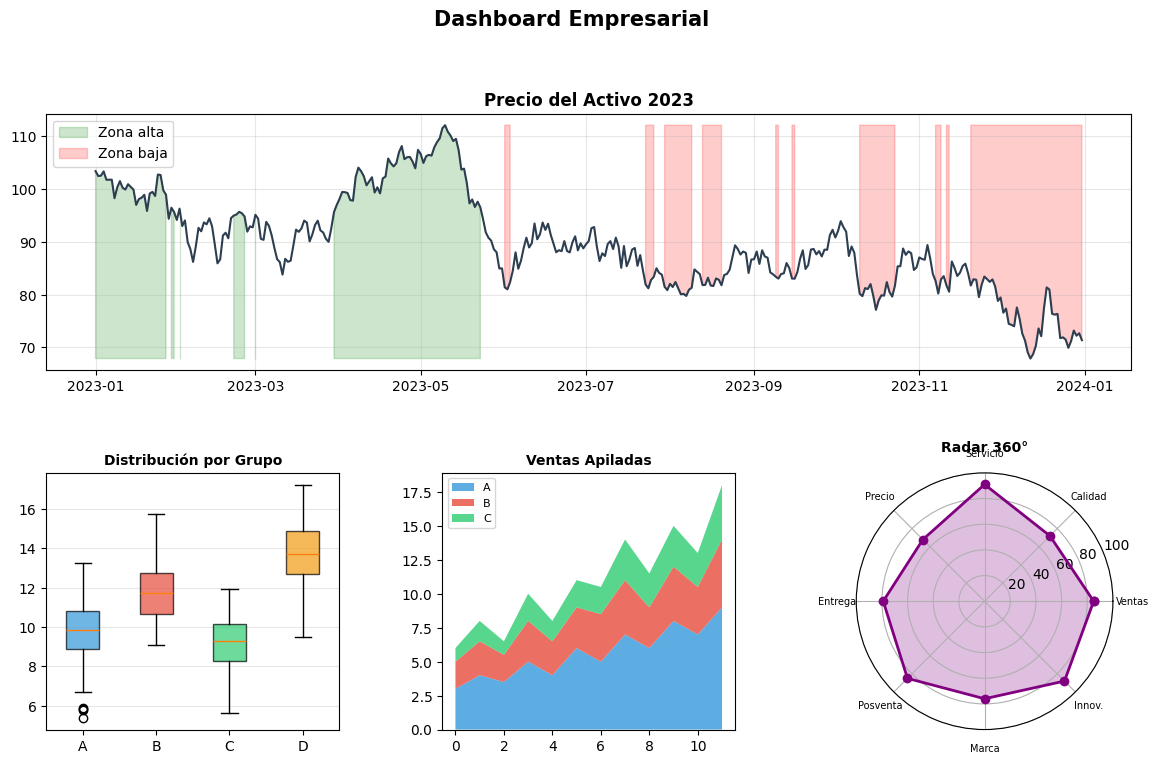

In [ ]:
np.random.seed(7)

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    nrows=2,     # 2 filas
    ncols=3,     # 3 columnas
    figure=fig,
    hspace=0.4,  # espacio entre filas
    wspace=0.35) # espacio entre columnas

# Axes que ocupa toda la fila superior
ax_top = fig.add_subplot(gs[0, :])   # fila 0, todas las columnas
ax_bl  = fig.add_subplot(gs[1, 0])   # fila 1, columna 0
ax_bm  = fig.add_subplot(gs[1, 1])   # fila 1, columna 1
ax_br  = fig.add_subplot(gs[1, 2])   # fila 1, columna 2

# Serie temporal (fila superior)
fechas = pd.date_range('2023-01-01', periods=365, freq='D')
# date_range(inicio, periodos, frecuencia)
# 'D' → diario | 'M' → mensual | 'H' → horario

precio = 100 + np.cumsum(np.random.randn(365) * 2)
# np.cumsum() → suma acumulada: cada elemento = suma de todos los anteriores
# Simula un precio con variación aleatoria (random walk)

ax_top.plot(fechas, precio, color='#2C3E50', linewidth=1.5)


ax_top.fill_between(fechas, precio, precio.min(),
                     where=(precio > np.percentile(precio, 75)),
                     # where      → solo rellena donde la condición es True
                     # percentile → valor que separa el 25% superior
                     color='green', alpha=0.2, label='Zona alta')

ax_top.fill_between(fechas, precio, precio.max(),
                     where=(precio < np.percentile(precio, 25)),
                     color='red', alpha=0.2, label='Zona baja')


ax_top.set_title('Precio del Activo 2023', fontweight='bold')
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# Boxplot (inferior izquierdo)
datos_g = [np.random.normal(mu, 1.5, 100) for mu in [10, 12, 9, 14]]
bp = ax_bl.boxplot(datos_g, labels=['A','B','C','D'], patch_artist=True)
# patch_artist=True → rellena las cajas con color
# Un boxplot muestra: mínimo, Q1, mediana, Q3, máximo y outliers

cols_box = ['#3498DB','#E74C3C','#2ECC71','#F39C12']
for patch, color in zip(bp['boxes'], cols_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax_bl.set_title('Distribución por Grupo', fontweight='bold', fontsize=10)
ax_bl.grid(axis='y', alpha=0.3)

# Área apilada (inferior central)
t = np.arange(12)
pa = [3,4,3.5,5,4,6,5,7,6,8,7,9]
pb = [2,2.5,2,3,2.5,3,3.5,4,3,4,3.5,5]
pc = [1,1.5,1,2,1.5,2,2,3,2.5,3,2.5,4]
ax_bm.stackplot(t, pa, pb, pc,
                labels=['A','B','C'],
                colors=['#3498DB','#E74C3C','#2ECC71'],
                alpha=0.8)
# stackplot → apila series, cada una sobre la anterior
ax_bm.set_title('Ventas Apiladas', fontweight='bold', fontsize=10)
ax_bm.legend(loc='upper left', fontsize=8)

# Polar (inferior derecho)
ax_br.remove()
ax_br = fig.add_subplot(gs[1, 2], projection='polar')
# projection='polar' → sistema de coordenadas polares (r, θ)

angulos = np.linspace(0, 2*np.pi, 8, endpoint=False)
vals    = [85, 72, 91, 68, 79, 85, 76, 88]
ang_c   = np.concatenate([angulos, [angulos[0]]])
val_c   = np.concatenate([vals, [vals[0]]])
ax_br.plot(ang_c, val_c, 'o-', linewidth=2, color='purple')
ax_br.fill(ang_c, val_c, alpha=0.25, color='purple')
ax_br.set_xticks(angulos)
ax_br.set_xticklabels(['Ventas','Calidad','Servicio','Precio',
                        'Entrega','Posventa','Marca','Innov.'], fontsize=7)
ax_br.set_ylim(0, 100)
ax_br.set_title('Radar 360°', fontweight='bold', fontsize=10, pad=15)

plt.suptitle('Dashboard Empresarial', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.2 Estilos predefinidos

## 2.3 rcParams — configuración global

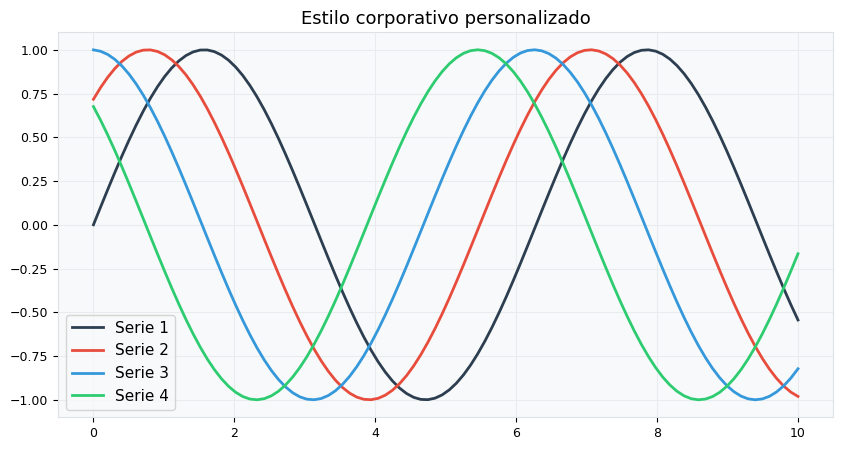

In [ ]:
original = plt.rcParams.copy()  # guardar para restaurar después

plt.rcParams.update({
    'figure.figsize':    [10, 5],      # Tamaño de la figura (ancho, alto)
    'figure.facecolor':  'white',     # Color de fondo externo
    'axes.facecolor':    '#F8F9FA',   # Color de fondo del área del gráfico
    'axes.edgecolor':    '#DEE2E6',   # Color de los bordes del gráfico
    'axes.grid':         True,        # Activar cuadrícula por defecto
    'grid.color':        '#E9ECEF',   # Color de las líneas de la cuadrícula
    'lines.linewidth':   2.0,         # Grosor de todas las líneas de datos
    'font.size':         11,          # Tamaño de fuente general
    'axes.titlesize':    13,          # Tamaño del título del gráfico
    'axes.labelsize':    11,          # Tamaño de etiquetas X e Y
    'xtick.labelsize':   9,           # Tamaño de los números en el eje X
    'ytick.labelsize':   9,           # Tamaño de los números en el eje Y
    'savefig.dpi':       150,         # Resolución para guardar imágenes
    'savefig.bbox':      'tight',     # Ajuste automático de bordes al guardar
})

# prop_cycle → ciclo de colores que se usa automáticamente
# Cuando agregas múltiples líneas, toman colores en orden
COLORES = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=COLORES)

fig, ax = plt.subplots()
for i in range(4):
    ax.plot(np.linspace(0,10,100), np.sin(np.linspace(0,10,100) + i*0.8),
            label=f'Serie {i+1}')
    # Cada línea toma automáticamente el siguiente color del cycler
ax.set_title('Estilo corporativo personalizado')
ax.legend()
plt.show()

plt.rcParams.update(original)  # restaurar configuración original

## 2.4 Colormaps — mapas de color

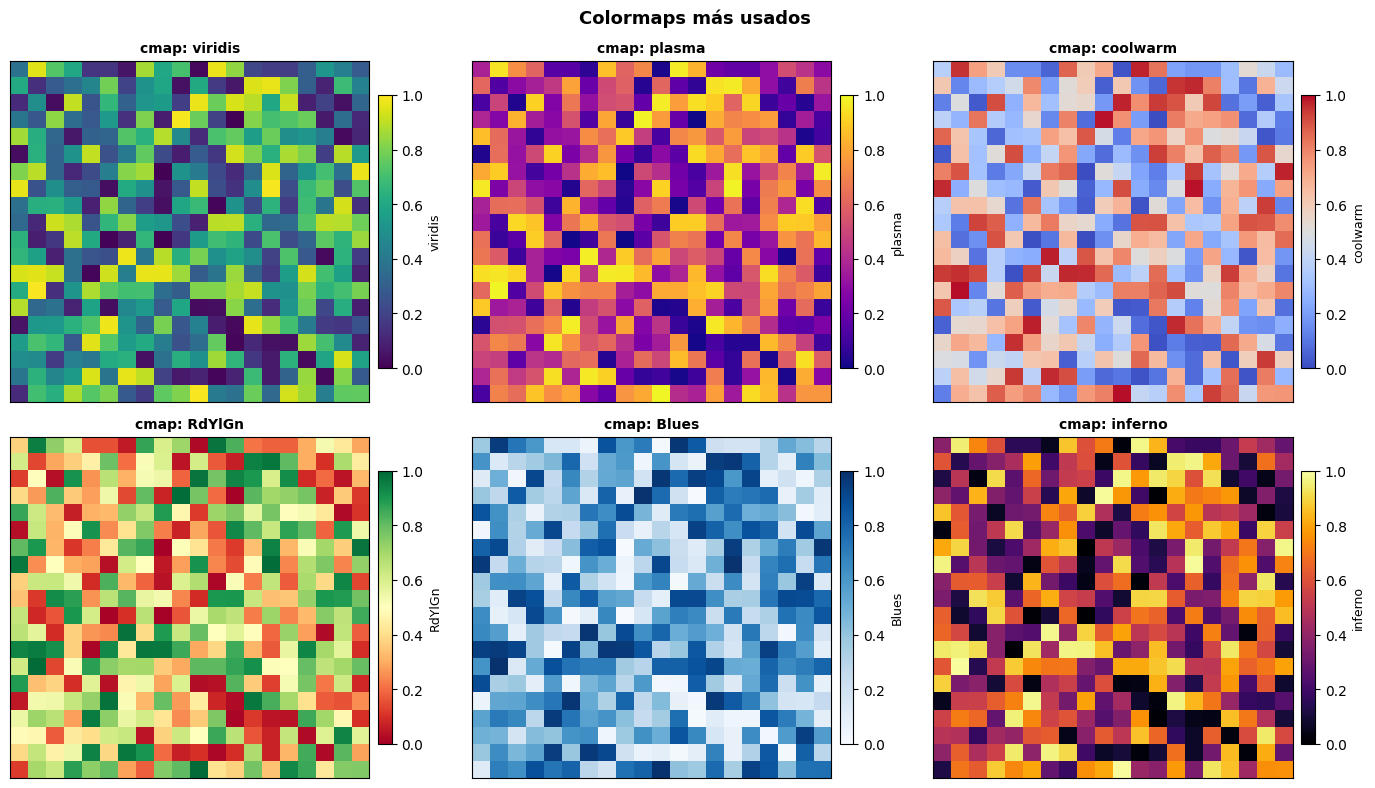

In [ ]:
# Un colormap convierte valores numéricos en colores
# Tipos:
#   Secuenciales:  'Blues','viridis','plasma'  → magnitud
#   Divergentes:   'RdBu','coolwarm'           → valores + y -
#   Cualitativos:  'Set1','tab10'              → categorías

np.random.seed(42)
Z = np.random.rand(20, 20)  # matriz 20x20 con valores [0, 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cmaps = ['viridis','plasma','coolwarm','RdYlGn','Blues','inferno']

for ax, cmap_n in zip(axes.flatten(), cmaps):
    im = ax.imshow(
        Z,
        cmap=cmap_n,
        # imshow() → muestra una matriz como imagen
        # Cada celda es un pixel coloreado según su valor
        interpolation='nearest',  # 'nearest'=cuadros | 'bilinear'=suave
        vmin=0, vmax=1,           # rango fijo del colormap
        aspect='auto')            # 'auto'=rellena el espacio

    cbar = plt.colorbar(
        im, ax=ax, shrink=0.8, pad=0.02)
    # colorbar() → barra que muestra la escala de colores
    # shrink=0.8 → 80% del alto del Axes

    cbar.set_label(cmap_n, fontsize=9)
    ax.set_title(f'cmap: {cmap_n}', fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    # set_xticks([]) → elimina marcas del eje

plt.suptitle('Colormaps más usados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Guardar figuras

PNG guardado: 31,459 bytes


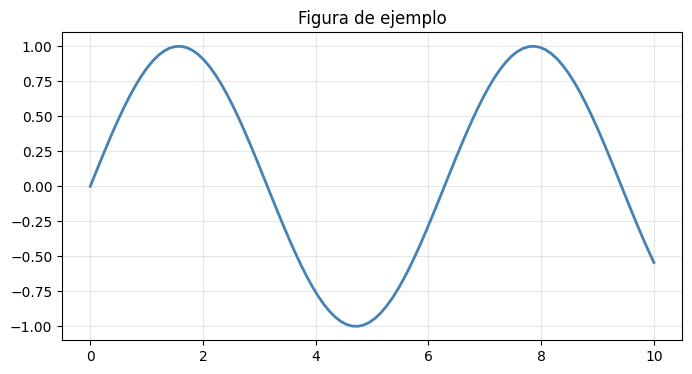

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.linspace(0,10,100), np.sin(np.linspace(0,10,100)),
        color='steelblue', linewidth=2)
ax.set_title('Figura de ejemplo')
ax.grid(True, alpha=0.3)

# PNG — mapa de bits, ideal para web
fig.savefig(
    'grafico.png',
    dpi=150,             # resolución: 72=pantalla | 150=media | 300=impresión
    bbox_inches='tight', # recorta espacio vacío alrededor
    facecolor='white',   # color de fondo
    transparent=False)   # True=fondo transparente

# SVG — vectorial, ideal para publicaciones
fig.savefig('grafico.svg', bbox_inches='tight')

# PDF — vectorial, ideal para documentos científicos
fig.savefig('grafico.pdf', bbox_inches='tight')

# En memoria (para APIs web, correos, etc.)
from io import BytesIO
buffer = BytesIO()
fig.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
buffer.seek(0)  # volver al inicio del buffer
datos_png = buffer.read()

print(f'PNG guardado: {len(datos_png):,} bytes')
plt.show()